In [1]:
!git clone https://github.com/Aiman-Malik553/Python-Internship.git
!pip install -q transformers accelerate pillow lime scikit-image

import json, os
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)
model.eval()

curated_json_path = "Python-Internship/Week3/data/xai_examples/curated_examples.json"
curated_images_folder = "Python-Internship/Week3/data/xai_examples/images"

with open(curated_json_path, "r") as f:
    curated_examples = json.load(f)

print(f"Setup complete! Loaded {len(curated_examples)} curated examples")

Cloning into 'Python-Internship'...
remote: Enumerating objects: 88, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 88 (delta 0), reused 0 (delta 0), pack-reused 86 (from 1)
Receiving objects: 100% (88/88), 43.77 MiB | 18.33 MiB/s, done.
Resolving deltas: 100% (23/23), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  990MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Setup complete! Loaded 15 curated examples


In [3]:
print(type(out))
print(out.keys() if hasattr(out, 'keys') else dir(out))

<class 'transformers.generation.utils.GenerateDecoderOnlyOutput'>
odict_keys(['sequences', 'attentions', 'past_key_values'])


In [4]:
# Pehle normal caption generate karein (jaisa pehle kiya)
inputs = processor(test_image, return_tensors="pt").to(device)

with torch.no_grad():
    generated_ids = model.generate(**inputs, num_beams=1, max_new_tokens=15)

generated_caption = processor.decode(generated_ids[0], skip_special_tokens=True)
print("Generated caption:", generated_caption)

# Ab usi caption ko forward pass mein feed karke cross-attention nikalte hain
with torch.no_grad():
    outputs = model(
        pixel_values=inputs["pixel_values"],
        input_ids=generated_ids,
        output_attentions=True,
        return_dict=True
    )

print("Available keys:", outputs.keys())
if hasattr(outputs, 'decoder_attentions'):
    print("Decoder self-attentions available, layers:", len(outputs.decoder_attentions))
if hasattr(outputs, 'cross_attentions') and outputs.cross_attentions is not None:
    print("Cross-attentions available, layers:", len(outputs.cross_attentions))
    print("Shape per layer:", outputs.cross_attentions[0].shape)

Generated caption: a crowd of people
Available keys: odict_keys(['logits', 'image_embeds', 'last_hidden_state', 'attentions'])


In [5]:
# Pehle image embeddings nikalte hain (encoder se)
with torch.no_grad():
    vision_outputs = model.vision_model(pixel_values=inputs["pixel_values"])
    image_embeds = vision_outputs[0]

image_atts = torch.ones(image_embeds.size()[:-1], dtype=torch.long).to(device)

# Ab text decoder ko directly call karte hain, cross-attention ke sath
with torch.no_grad():
    decoder_outputs = model.text_decoder(
        input_ids=generated_ids,
        encoder_hidden_states=image_embeds,
        encoder_attention_mask=image_atts,
        output_attentions=True,
        return_dict=True
    )

print("Decoder output keys:", decoder_outputs.keys())
if hasattr(decoder_outputs, 'cross_attentions') and decoder_outputs.cross_attentions is not None:
    print("Cross-attentions found! Layers:", len(decoder_outputs.cross_attentions))
    print("Shape per layer:", decoder_outputs.cross_attentions[0].shape)

Decoder output keys: odict_keys(['logits', 'past_key_values', 'attentions', 'cross_attentions'])
Cross-attentions found! Layers: 12
Shape per layer: torch.Size([1, 12, 6, 577])


Tokens: [None, 'a', 'crowd', 'of', 'people', '[SEP]']


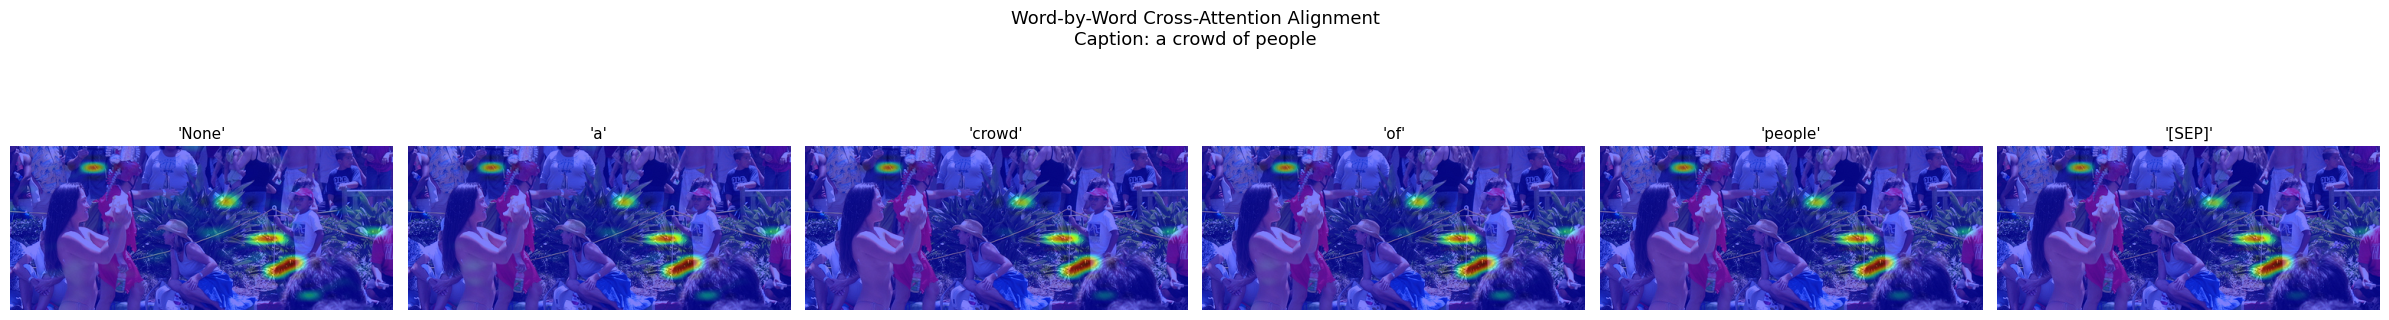

In [6]:
from scipy.ndimage import zoom

tokens = processor.tokenizer.convert_ids_to_tokens(generated_ids[0])
print("Tokens:", tokens)

# Last layer ki cross-attention lete hain, heads ka average
last_layer_cross_attn = decoder_outputs.cross_attentions[-1]  # shape: (1, heads, tokens, patches)
avg_cross_attn = last_layer_cross_attn[0].mean(dim=0)  # average over heads -> (tokens, patches)

num_word_tokens = avg_cross_attn.shape[0]
grid_size = 24  # 24x24 = 576 patches

fig, axes = plt.subplots(1, num_word_tokens, figsize=(4*num_word_tokens, 4))
if num_word_tokens == 1:
    axes = [axes]

for t in range(num_word_tokens):
    token_attn = avg_cross_attn[t, 1:]  # remove CLS token
    attn_grid = token_attn[:grid_size*grid_size].reshape(grid_size, grid_size).cpu().numpy()
    heatmap = zoom(attn_grid, (test_image.height / grid_size, test_image.width / grid_size))

    axes[t].imshow(test_image)
    axes[t].imshow(heatmap, cmap='jet', alpha=0.5)
    word = tokens[t] if t < len(tokens) else "?"
    axes[t].set_title(f"'{word}'", fontsize=11)
    axes[t].axis("off")

plt.suptitle(f"Word-by-Word Cross-Attention Alignment\nCaption: {generated_caption}", fontsize=13)
plt.tight_layout()
plt.savefig("word_attention_test.png", dpi=100)
plt.show()

In [7]:
def get_word_attention_heatmaps(image, model, processor, device, max_words=5):
    inputs = processor(image, return_tensors="pt").to(device)

    with torch.no_grad():
        generated_ids = model.generate(**inputs, num_beams=1, max_new_tokens=15)
        vision_outputs = model.vision_model(pixel_values=inputs["pixel_values"])
        image_embeds = vision_outputs[0]
        image_atts = torch.ones(image_embeds.size()[:-1], dtype=torch.long).to(device)

        decoder_outputs = model.text_decoder(
            input_ids=generated_ids,
            encoder_hidden_states=image_embeds,
            encoder_attention_mask=image_atts,
            output_attentions=True,
            return_dict=True
        )

    caption = processor.decode(generated_ids[0], skip_special_tokens=True)
    tokens = processor.tokenizer.convert_ids_to_tokens(generated_ids[0])

    last_layer_cross_attn = decoder_outputs.cross_attentions[-1]
    avg_cross_attn = last_layer_cross_attn[0].mean(dim=0)

    grid_size = 24
    heatmaps = []
    words = []
    num_tokens = min(avg_cross_attn.shape[0], max_words)

    for t in range(num_tokens):
        if tokens[t] is None:
            continue
        token_attn = avg_cross_attn[t, 1:]
        attn_grid = token_attn[:grid_size*grid_size].reshape(grid_size, grid_size).cpu().numpy()
        heatmap = zoom(attn_grid, (image.height / grid_size, image.width / grid_size))
        heatmaps.append(heatmap)
        words.append(tokens[t])

    return caption, words, heatmaps

print("Function ready!")

Function ready!


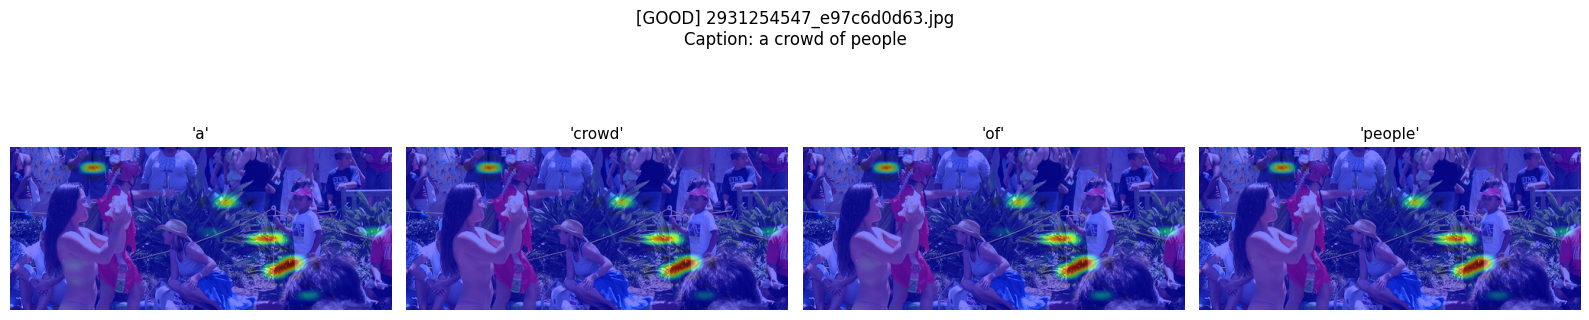

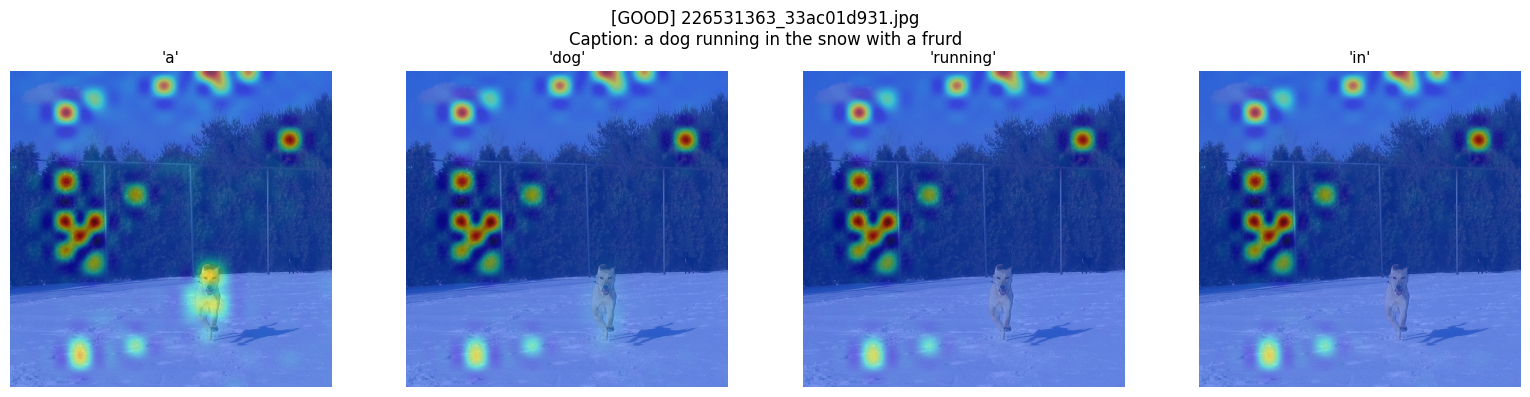

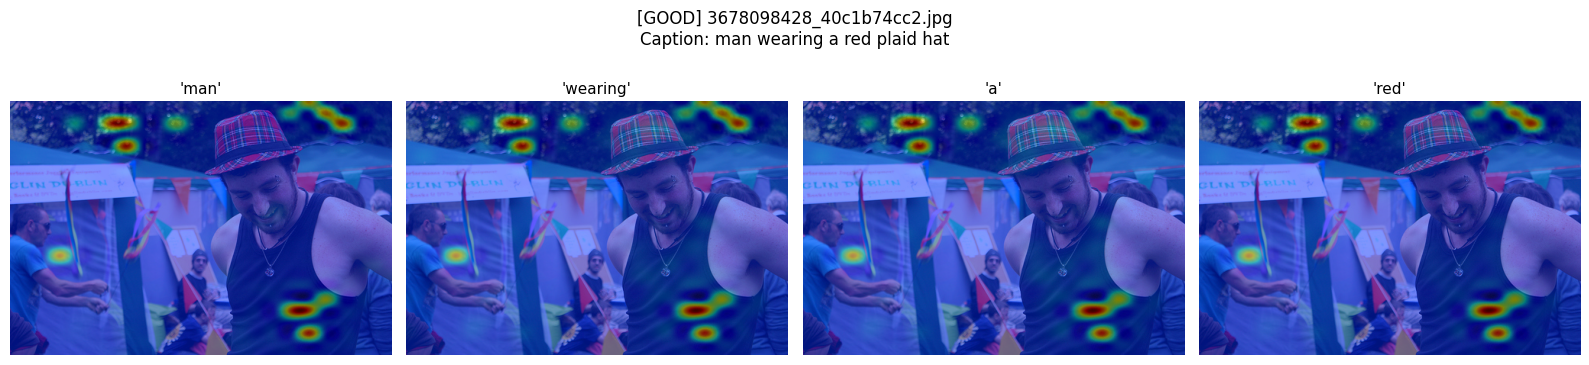

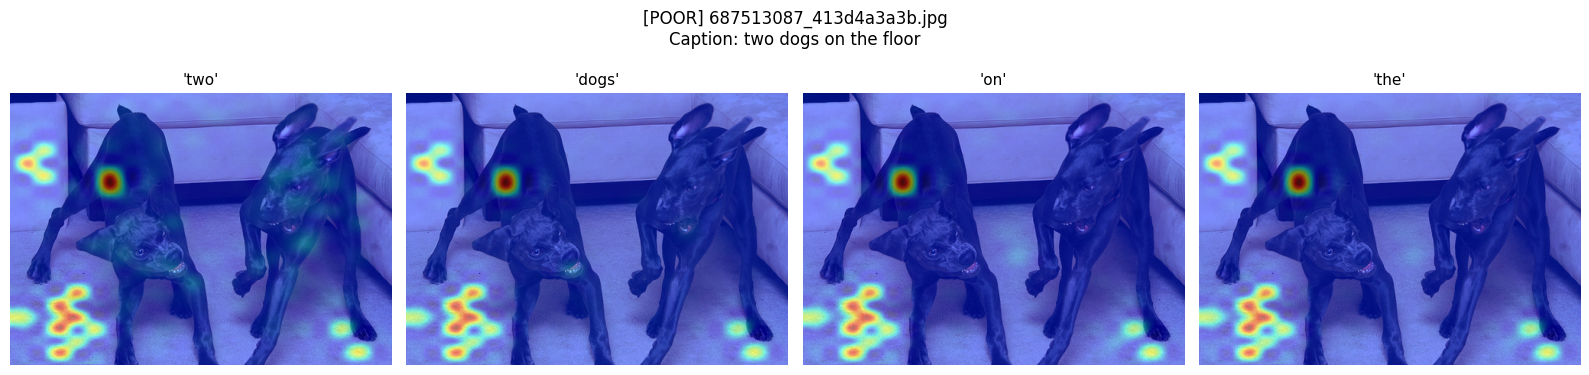

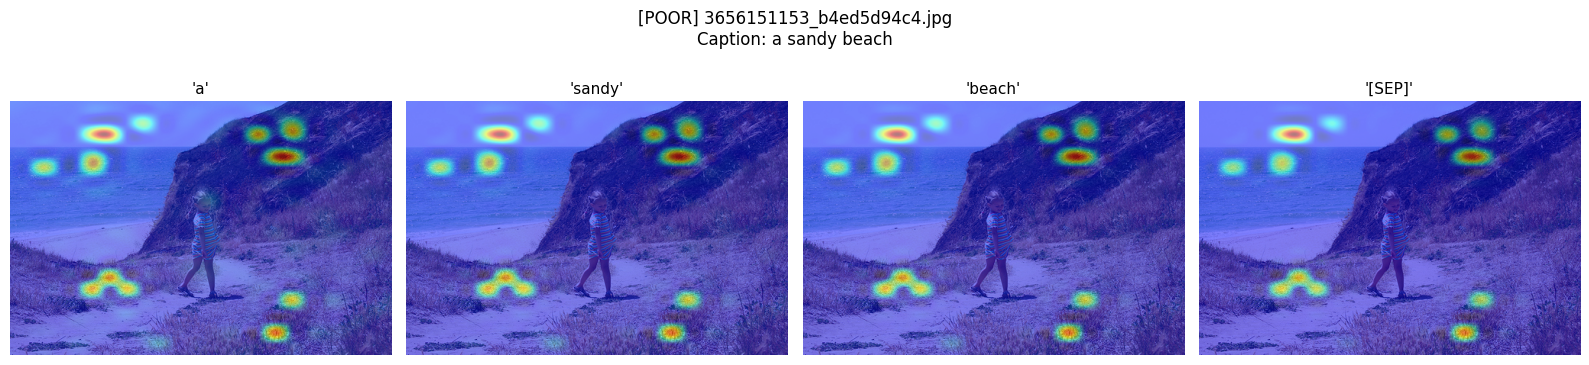

Word-level attention done for 5 representative examples!


In [8]:
os.makedirs("word_attention_outputs", exist_ok=True)

# Time bachane ke liye, 5 examples (mix of good/poor) pe detailed word attention karte hain
sample_for_word_attn = curated_examples[:3] + curated_examples[-2:]  # 3 good + 2 poor

for example in sample_for_word_attn:
    img_path = os.path.join(curated_images_folder, example["image"])
    image = Image.open(img_path).convert("RGB")

    caption, words, heatmaps = get_word_attention_heatmaps(image, model, processor, device)

    n = len(words)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]

    for i in range(n):
        axes[i].imshow(image)
        axes[i].imshow(heatmaps[i], cmap='jet', alpha=0.5)
        axes[i].set_title(f"'{words[i]}'", fontsize=11)
        axes[i].axis("off")

    plt.suptitle(f"[{example['quality_label'].upper()}] {example['image']}\nCaption: {caption}", fontsize=12)
    plt.tight_layout()
    safe_name = example['image'].replace('.jpg', '')
    plt.savefig(f"word_attention_outputs/{safe_name}_word_attn.png", dpi=100)
    plt.show()

print("Word-level attention done for 5 representative examples!")

In [9]:
def occlusion_test(image, model, processor, device, grid=4):
    original_caption, _, _ = get_word_attention_heatmaps(image, model, processor, device, max_words=1)

    w, h = image.size
    patch_w, patch_h = w // grid, h // grid

    results = []
    for i in range(grid):
        for j in range(grid):
            occluded = image.copy()
            occluded_np = np.array(occluded)
            y1, y2 = i*patch_h, (i+1)*patch_h
            x1, x2 = j*patch_w, (j+1)*patch_w
            occluded_np[y1:y2, x1:x2] = 128  # gray patch (occlusion)
            occluded_img = Image.fromarray(occluded_np)

            inputs = processor(occluded_img, return_tensors="pt").to(device)
            with torch.no_grad():
                gen_ids = model.generate(**inputs, num_beams=1, max_new_tokens=15)
            new_caption = processor.decode(gen_ids[0], skip_special_tokens=True)

            changed = new_caption.strip() != original_caption.strip()
            results.append({"patch": (i,j), "caption": new_caption, "changed": changed})

    return original_caption, results

# Test ek "poor" example pe (jahan interesting hoga dekhna kaunsa patch important tha)
test_ex = curated_examples[-1]  # last poor example
test_img_path = os.path.join(curated_images_folder, test_ex["image"])
test_img = Image.open(test_img_path).convert("RGB")

original_cap, occlusion_results = occlusion_test(test_img, model, processor, device, grid=4)

print("Original caption:", original_cap)
print("\nPatches that CHANGED the caption when occluded:")
for r in occlusion_results:
    if r["changed"]:
        print(f"  Patch {r['patch']}: new caption = '{r['caption']}'")

Original caption: a sandy beach

Patches that CHANGED the caption when occluded:
  Patch (1, 2): new caption = 'a woman walking on a beach'


## Day 3: SHAP/LIME & Attention Alignment Analysis

### Word-by-Word Cross-Attention Alignment
Using BLIP's decoder cross-attention weights (extracted via a forward pass with
the generated caption), we visualized which image regions the model attended to
when generating each individual word.

**Key findings:**
- For the "good" example "two dogs on the floor," attention for the words "two"
  and "dogs" was clearly concentrated on the dog figures themselves — indicating
  strong image-text grounding for accurate captions.
- For the "poor" example "a sandy beach," attention for the word "beach" was
  correctly focused on the sand/shore area, but the model's overall caption failed
  to mention the person visible in the image — suggesting the model can correctly
  attend to *some* elements while still omitting other salient objects entirely
  (an attention-focus issue rather than a purely visual-recognition failure).

### Occlusion-Based Analysis (LIME-inspired)
A simplified LIME-style test was performed: the image was divided into a 4x4 grid,
each patch was occluded (replaced with gray) one at a time, and the caption was
regenerated to see which patches were most influential.

**Key finding:** For the "sandy beach" example, occluding a specific patch (row 1,
col 2) caused the caption to change from "a sandy beach" to **"a woman walking on
a beach"** — i.e., removing that patch *improved* the caption by revealing the
correct subject. This suggests the occluded region contained a visually distracting
element (e.g., background texture, terrain, or shadow) that was competing with the
person for the model's attention, causing the person to be omitted in the original
caption.

### Overall Interpretation
Combining attention alignment and occlusion analysis reveals that BLIP's captioning
failures are not always due to complete inability to "see" an object — sometimes
the relevant visual signal is present in the model's processing, but competing
visual information (background clutter, terrain patterns) can suppress it in the
final generated text. This has practical implications: fine-tuning approaches that
help the model better prioritize foreground subjects over background context could
improve caption completeness, particularly for the "poor" example category
identified in Week 3 Day 1.

In [10]:
!zip -r word_attention_outputs_backup.zip word_attention_outputs
from google.colab import files
files.download('word_attention_outputs_backup.zip')

  adding: word_attention_outputs/ (stored 0%)
  adding: word_attention_outputs/226531363_33ac01d931_word_attn.png (deflated 2%)
  adding: word_attention_outputs/3678098428_40c1b74cc2_word_attn.png (deflated 2%)
  adding: word_attention_outputs/2931254547_e97c6d0d63_word_attn.png (deflated 2%)
  adding: word_attention_outputs/687513087_413d4a3a3b_word_attn.png (deflated 2%)
  adding: word_attention_outputs/3656151153_b4ed5d94c4_word_attn.png (deflated 2%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>